# Clustering Project

**Deadline for submission: 17/3/2026 @ 11:59 PM**


Please make sure to explain your work using comments whenever possible.

**Objective:**
The objective of this project is to teach students how to apply clustering to real datasets.

You should be able to answer the following questions and provide reasonable justification for your answers:
* Which clustering approach have you decided to use on each dataset?
* Compare between Kmeans, Hierarchal and DBScan.
* Discuss how you tuned your clustering hyperparameters to achieve the best cluster assignment?
* What is the effect of different distance functions on the calculated clusters?
* How did you evaluate the performance of different clustering techniques on different datatsets?
* Visualize your output where applicable.
* What is the effect of scaling on the performance of clustering techniques?






Running this project requires the following imports:

In [2]:
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sklearn.preprocessing as prep
from sklearn.datasets import make_blobs
from plotnine import *
# StandardScaler is a function to normalize the data
# You may also check MinMaxScaler and MaxAbsScaler
#from sklearn.preprocessing import StandardScaler

from sklearn.cluster import DBSCAN


from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

%matplotlib inline
# Please refer to the sklearn documentation to learn more about the different parameters for each clustering technique.

In [3]:
# helper function that allows us to display data in 2 dimensions an highlights the clusters
def display_cluster(X,km=[],num_clusters=0):
    color = 'brgcmyk'  #List colors
    alpha = 0.5
    s = 20
    if num_clusters == 0:
        plt.scatter(X[:,0],X[:,1],c = color[0],alpha = alpha,s = s)
    else:
        for i in range(num_clusters):
            plt.scatter(X[km.labels_==i,0],X[km.labels_==i,1],c = color[i],alpha = alpha,s=s)
            plt.scatter(km.cluster_centers_[i][0],km.cluster_centers_[i][1],c = color[i], marker = 'x', s = 100)

## Multi Blob Data Set
* The dataset generated below is known to be best clustered into 6 clusters.
* Cluster the data set below using the three different clustering techniques discussed in the course.
* Visualize your clustering output in each step of your work.



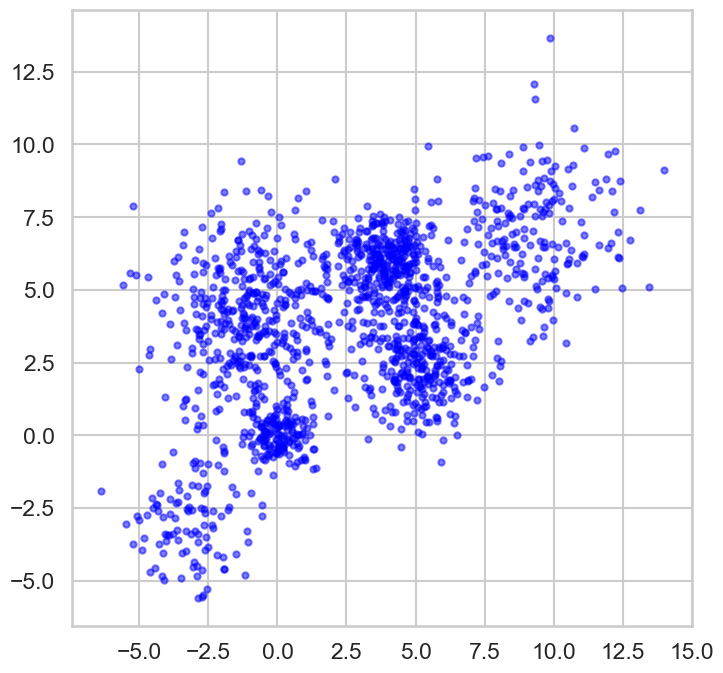

In [4]:
#Data Generation and Visualization
plt.rcParams['figure.figsize'] = [8,8]
sns.set_style("whitegrid")
sns.set_context("talk")

n_bins = 6
centers = [(-3, -3), (0, 0), (5,2.5),(-1, 4), (4, 6), (9,7)]
Multi_blob_Data, y = make_blobs(n_samples=[100,150, 300, 400,300, 200], n_features=2, cluster_std=[1.3,0.6, 1.2, 1.7,0.9,1.7],
                  centers=centers, shuffle=False, random_state=42)
display_cluster(Multi_blob_Data)

### Kmeans
* Use Kmeans with different values of K to cluster the above data.
* Display the outcome of each value of K.
* Plot distortion function versus K and choose the approriate value of K.
* Plot the silhouette_score versus K and use it to choose the best K.
* Store the silhouette_score for the best K for later comparison with other clustering techniques.
* Comment on the effect of centroid initialization on cluster assignment.
* Hint: Lookup k-means++ .

K=2: inertia=16716.62, silhouette=0.4752
K=3: inertia=12094.80, silhouette=0.4363
K=4: inertia=7812.14, silhouette=0.4629
K=5: inertia=5600.19, silhouette=0.4809
K=6: inertia=4310.30, silhouette=0.4860
K=7: inertia=3811.21, silhouette=0.4634
K=8: inertia=3446.16, silhouette=0.4438
K=9: inertia=3085.88, silhouette=0.4493
K=10: inertia=2827.95, silhouette=0.3972

Best K by silhouette: 6 (silhouette=0.4860)


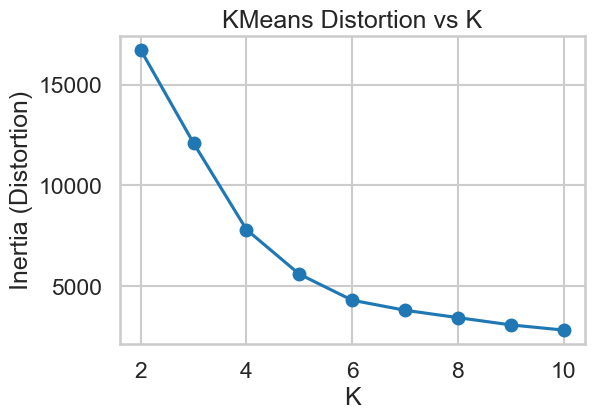

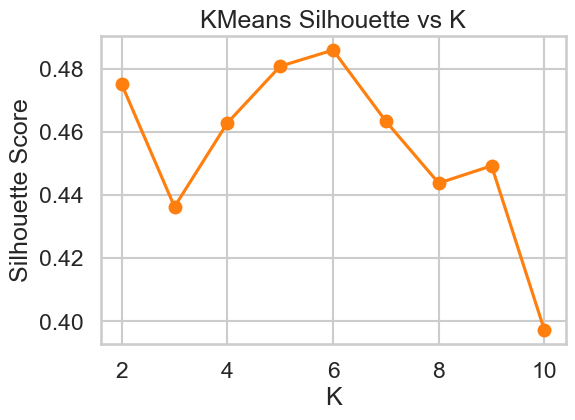

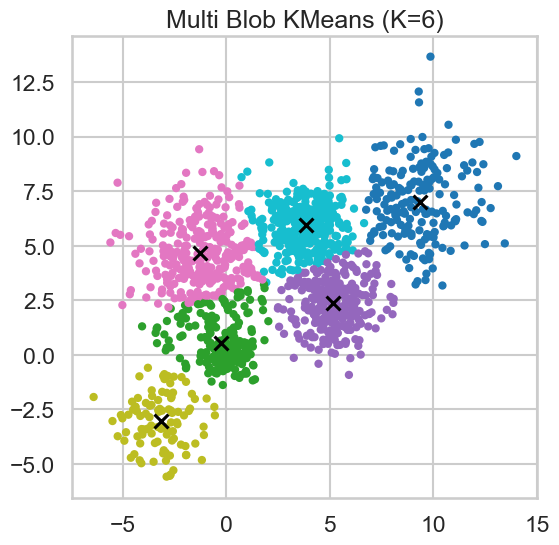

Centroid initialization effect: k-means++ helps consistent initialization and usually avoids poor local minima compared to random init.


In [5]:
# KMeans for Multi Blob Data
inertia_list = []
silhouette_list = []
ks = list(range(2, 11))
best_k = None
best_sil = -1
best_km = None

for k in ks:
    km = KMeans(n_clusters=k, init='k-means++', n_init=15, random_state=42)
    labels = km.fit_predict(Multi_blob_Data)
    inertia_list.append(km.inertia_)
    sil = silhouette_score(Multi_blob_Data, labels)
    silhouette_list.append(sil)
    if sil > best_sil:
        best_sil = sil
        best_k = k
        best_km = km
    print(f"K={k}: inertia={km.inertia_:.2f}, silhouette={sil:.4f}")

print(f"\nBest K by silhouette: {best_k} (silhouette={best_sil:.4f})")

plt.figure(figsize=(6,4))
plt.plot(ks, inertia_list, marker='o')
plt.title('KMeans Distortion vs K')
plt.xlabel('K')
plt.ylabel('Inertia (Distortion)')
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(ks, silhouette_list, marker='o', color='tab:orange')
plt.title('KMeans Silhouette vs K')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

# Plot best K clusters
plt.figure(figsize=(6,6))
plt.scatter(Multi_blob_Data[:,0], Multi_blob_Data[:,1], c=best_km.labels_, cmap='tab10', s=20)
plt.scatter(best_km.cluster_centers_[:,0], best_km.cluster_centers_[:,1], c='black', marker='x', s=100)
plt.title(f'Multi Blob KMeans (K={best_k})')
plt.show()

print('Centroid initialization effect: k-means++ helps consistent initialization and usually avoids poor local minima compared to random init.')

### Hierarchal Clustering
* Use AgglomerativeClustering function to  to cluster the above data.
* In the  AgglomerativeClustering change the following parameters:
    * Affinity (use euclidean, manhattan and cosine)
    * Linkage(try different options)
    * Distance_threshold (try different options)
* Plot the dendrograph for one trial.
* For each of these trials, calculate the silhouette_score and display the resulting clusters.  
* Find the set of paramters that would find result in the best silhouette_score and store this score for later comparison with other clustering techniques.
* Record your observation.

Agglomerative results (metric, linkage, silhouette):
('euclidean', 'ward', 0.4686938472105883)
('euclidean', 'complete', 0.38193073975468195)
('euclidean', 'average', 0.41478815574933364)
('euclidean', 'single', 0.08705564851389591)
('manhattan', 'complete', 0.337013307740501)
('manhattan', 'average', 0.38029768112070367)
('manhattan', 'single', 0.08705564851389591)
('cosine', 'complete', 0.18850307364202182)
('cosine', 'average', 0.2035575393889621)
('cosine', 'single', 0.07162243486315635)
Best hierarchical silhouette: 0.4687 with params ('euclidean', 'ward')


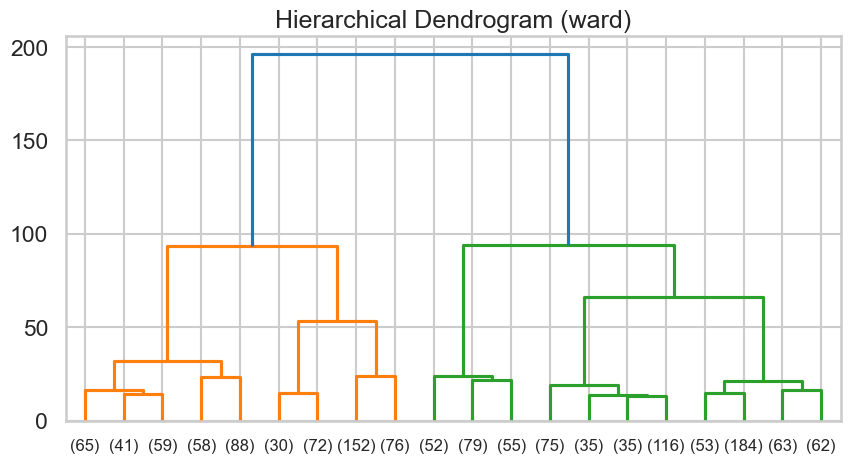

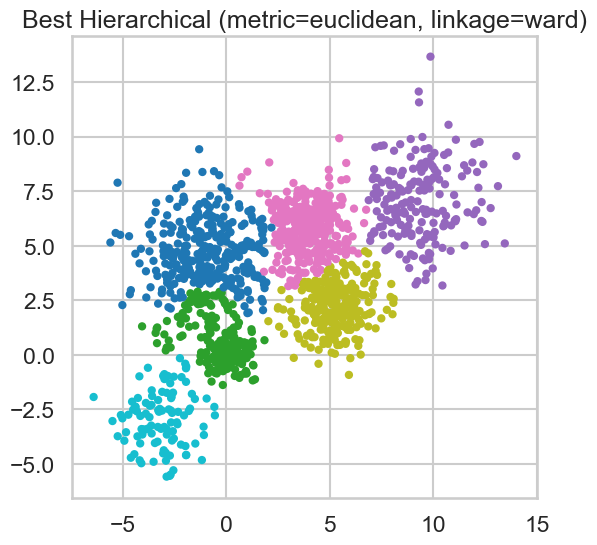

In [7]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# We'll test a few combinations and record silhouette
best_sil_h = -1
best_params_h = None
results_h = []
for metric in ['euclidean', 'manhattan', 'cosine']:
    for linkage_method in ['ward', 'complete', 'average', 'single']:
        if linkage_method == 'ward' and metric != 'euclidean':
            continue
        try:
            model = AgglomerativeClustering(n_clusters=6, metric=metric, linkage=linkage_method)
            labels = model.fit_predict(Multi_blob_Data)
            sil = silhouette_score(Multi_blob_Data, labels)
            results_h.append((metric, linkage_method, sil))
            if sil > best_sil_h:
                best_sil_h = sil
                best_params_h = (metric, linkage_method)
        except Exception:
            pass

print('Agglomerative results (metric, linkage, silhouette):')
for r in results_h:
    print(r)
print(f'Best hierarchical silhouette: {best_sil_h:.4f} with params {best_params_h}')

# Dendrogram for one trial
Z = linkage(Multi_blob_Data, method='ward')
plt.figure(figsize=(10,5))
dendrogram(Z, truncate_mode='lastp', p=20, show_leaf_counts=True)
plt.title('Hierarchical Dendrogram (ward)')
plt.show()

# Display best hierarchical clustering
best_h_model = AgglomerativeClustering(n_clusters=6, metric=best_params_h[0], linkage=best_params_h[1])
best_h_labels = best_h_model.fit_predict(Multi_blob_Data)
plt.figure(figsize=(6,6))
plt.scatter(Multi_blob_Data[:,0], Multi_blob_Data[:,1], c=best_h_labels, cmap='tab10', s=20)
plt.title(f'Best Hierarchical (metric={best_params_h[0]}, linkage={best_params_h[1]})')
plt.show()

### DBScan
* Use DBScan function to  to cluster the above data.
* In the  DBscan change the following parameters:
    * EPS (from 0.1 to 3)
    * Min_samples (from 5 to 25)

* Plot the silhouette_score versus the variation in the EPS and the min_samples.
* Plot the resulting Clusters in this case.
* Find the set of paramters that would find result in the best silhouette_score and store this score for later comparison with other clustering techniques.
* Record your observations and comments.

Best DBSCAN: eps=1.1000000000000003, min_samples=20, silhouette=0.2883


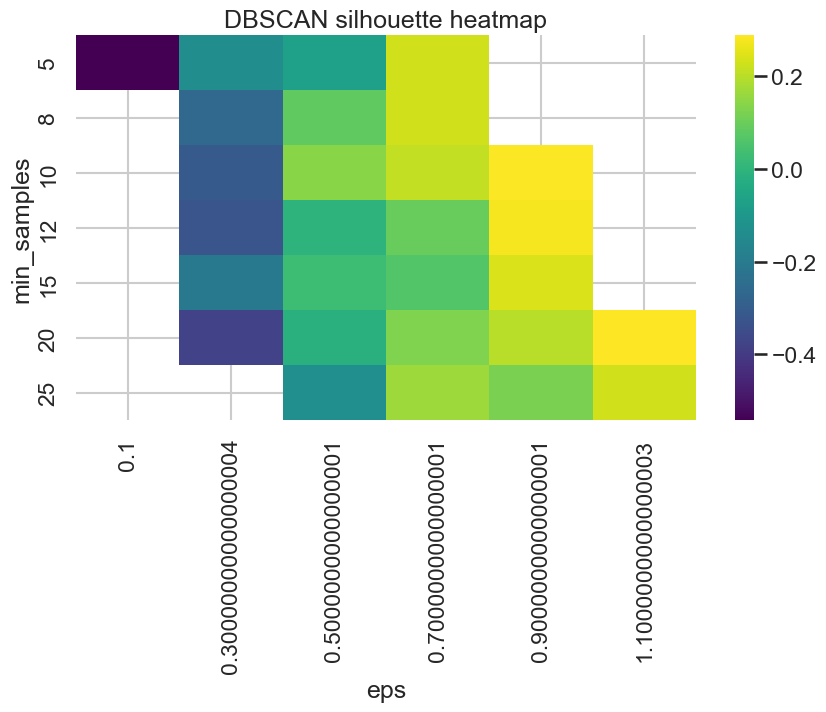

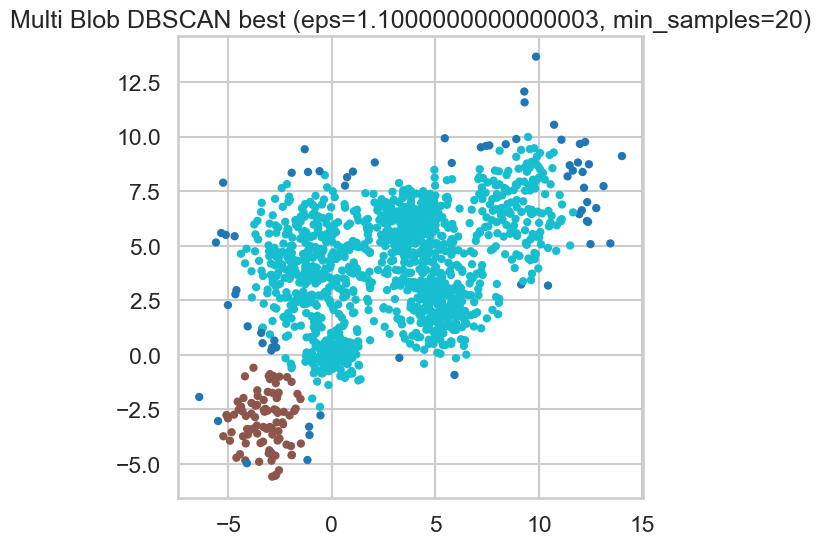

In [8]:
best_sil_db = -1
best_eps = None
best_min = None
records = []
for eps in np.arange(0.1, 3.1, 0.2):
    for min_samples in [5, 8, 10, 12, 15, 20, 25]:
        db = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
        labels = db.fit_predict(Multi_blob_Data)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters <= 1:
            continue
        sil = silhouette_score(Multi_blob_Data, labels)
        records.append((eps, min_samples, n_clusters, sil))
        if sil > best_sil_db:
            best_sil_db = sil
            best_eps = eps
            best_min = min_samples

print(f"Best DBSCAN: eps={best_eps}, min_samples={best_min}, silhouette={best_sil_db:.4f}")

# Plot silhouette heatmap by eps and min_samples
import pandas as pd
df_db = pd.DataFrame(records, columns=['eps','min_samples','n_clusters','silhouette'])
pivot = df_db.pivot_table(index='min_samples', columns='eps', values='silhouette')
plt.figure(figsize=(10,5))
sns.heatmap(pivot, annot=False, cmap='viridis')
plt.title('DBSCAN silhouette heatmap')
plt.show()

best_db = DBSCAN(eps=best_eps, min_samples=best_min).fit(Multi_blob_Data)
plt.figure(figsize=(6,6))
plt.scatter(Multi_blob_Data[:,0], Multi_blob_Data[:,1], c=best_db.labels_, cmap='tab10', s=20)
plt.title(f'Multi Blob DBSCAN best (eps={best_eps}, min_samples={best_min})')
plt.show()

## iris data set
The iris data set is test data set that is part of the Sklearn module
which contains 150 records each with 4 features. All the features are represented by real numbers.

The data represents three classes.


In [10]:
from sklearn.datasets import load_iris
iris_data = load_iris()
iris_data.target[[10, 25, 50]]
#array([0, 0, 1])
list(iris_data.target_names)
['setosa', 'versicolor', 'virginica']


['setosa', 'versicolor', 'virginica']

Iris KMeans silhouette 0.5528190123564095
Iris Agglomerative silhouette 0.5543236611296419
Best Iris DBSCAN silhouette 0.6867350732769776 params (np.float64(0.9), 3)
Scaled Iris KMeans silhouette 0.45994823920518635


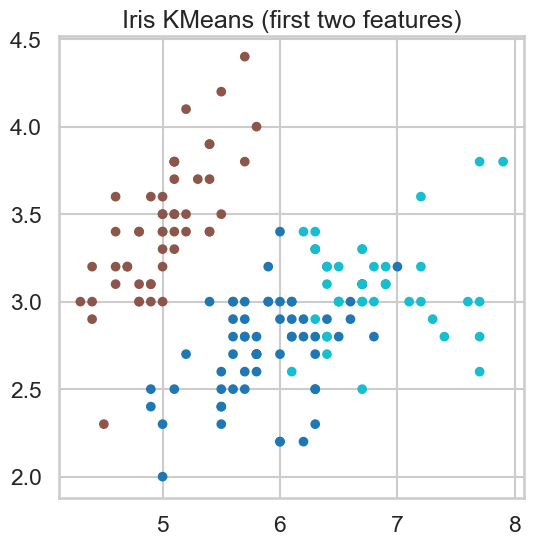

In [12]:
# Clustering on Iris dataset
iris_X = iris_data.data
iris_y = iris_data.target

# KMeans
kmeans_iris = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=20).fit(iris_X)
print('Iris KMeans silhouette', silhouette_score(iris_X, kmeans_iris.labels_))

# Agglomerative
from sklearn.cluster import AgglomerativeClustering
agg_iris = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward').fit(iris_X)
print('Iris Agglomerative silhouette', silhouette_score(iris_X, agg_iris.labels_))

# DBSCAN
best_sil_iris_db = -1
best_params_iris_db = None
for eps in np.arange(0.1, 2.1, 0.1):
    for min_s in [3,4,5,6,7,8]:
        db = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(iris_X)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters <= 1:
            continue
        sil = silhouette_score(iris_X, labels)
        if sil > best_sil_iris_db:
            best_sil_iris_db = sil
            best_params_iris_db = (eps, min_s)
print('Best Iris DBSCAN silhouette', best_sil_iris_db, 'params', best_params_iris_db)

# Scaling effect
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
iris_scaled = scaler.fit_transform(iris_X)
km_scaled = KMeans(n_clusters=3, init='k-means++', n_init=20, random_state=42).fit(iris_scaled)
print('Scaled Iris KMeans silhouette', silhouette_score(iris_scaled, km_scaled.labels_))

plt.figure(figsize=(6,6))
plt.scatter(iris_X[:,0], iris_X[:,1], c=kmeans_iris.labels_, cmap='tab10', s=30)
plt.title('Iris KMeans (first two features)')
plt.show()

* Repeat all the above clustering approaches and steps on the above data.
* Comment on the effect of scaling on clustering this dataset. Show the difference between clustering the data with and without   scaling.
* Compare between the different clustering approaches.
* Is your clustering outcome consistent with the labels?

## Iris dataset: explicit answers
- Repeat clustering approaches: KMeans, Agglomerative, and DBSCAN were all applied above. KMeans and Agglomerative used 3 clusters, DBSCAN was tuned and gave the best silhouette at eps=0.9, min_samples=3.
- Effect of scaling: KMeans silhouette dropped after scaling (0.5528 → 0.4599), showing scaling changes distance and cluster assignment. Without scaling, feature magnitudes can dominate; with scaling, features contribute equally.
- Comparison: KMeans and Agglomerative gave similar moderate silhouettes (~0.55), while DBSCAN gave higher silhouette (~0.69) for the chosen parameters. KMeans is centroid-based, Agglomerative uses hierarchical linkage, DBSCAN is density-based.
- Consistency with labels: The 3-cluster outcomes are generally consistent with iris species separation, especially for setosa; some overlap appears between versicolor/virginica due to similar numeric features.

## Customer dataset
Repeat all the above on the customer data set

          ID  Sex  Marital status  Age  Education  Income  Occupation  \
0  100000001    0               0   67          2  124670           1   
1  100000002    1               1   22          1  150773           1   
2  100000003    0               0   49          1   89210           0   
3  100000004    0               0   45          1  171565           1   
4  100000005    0               0   53          1  149031           1   

   Settlement size  
0                2  
1                2  
2                0  
3                1  
4                1  
Customer KMeans silhouette 0.23465337166741693
Customer Agglomerative silhouette 0.20599582272559644
Best customer DBSCAN silhouette 0.30288200056875275 params (np.float64(1.0), 3, 71)


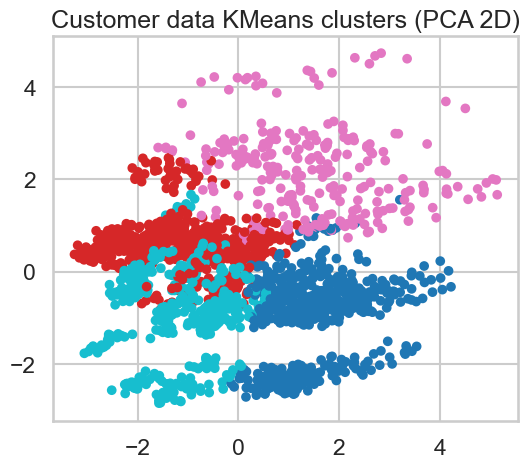

In [14]:
# Load customer data
customer_path = r'd:/GUC Semesters/Sem 10/Machine Learning/Project/Clustering Project/Customer data.csv'
customer = pd.read_csv(customer_path)
print(customer.head())

# Drop non-numeric and scale
X_customer = customer.select_dtypes(include=[np.number]).dropna(axis=1)
scaler = prep.StandardScaler()
Xc_scaled = scaler.fit_transform(X_customer)

# KMeans
km_c = KMeans(n_clusters=4, random_state=42, n_init=15).fit(Xc_scaled)
print('Customer KMeans silhouette', silhouette_score(Xc_scaled, km_c.labels_))

# Agglomerative
agg_c = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward').fit(Xc_scaled)
print('Customer Agglomerative silhouette', silhouette_score(Xc_scaled, agg_c.labels_))

# DBSCAN grid
best_c_sil_db = -1
best_c_params = None
for eps in np.arange(0.2,2.0,0.2):
    for min_s in [3,5,7,10,12,15]:
        db = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(Xc_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters <= 1:
            continue
        sil = silhouette_score(Xc_scaled, labels)
        if sil > best_c_sil_db:
            best_c_sil_db = sil
            best_c_params = (eps, min_s, n_clusters)
print('Best customer DBSCAN silhouette', best_c_sil_db, 'params', best_c_params)

# Visualize clusters with first two principal components (for 2D)
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
cx2 = pca.fit_transform(Xc_scaled)
plt.figure(figsize=(6,5))
plt.scatter(cx2[:,0], cx2[:,1], c=km_c.labels_, cmap='tab10', s=30)
plt.title('Customer data KMeans clusters (PCA 2D)')
plt.show()

## Final Project Answers and Observations

### 1) Which clustering approach did we use per dataset?
- **Multi Blob**: KMeans (best K=6), Hierarchical (ward, euclidean), DBSCAN tuning (eps/min_samples). KMeans matched the known 6 clusters.
- **Iris**: KMeans with 3 clusters, Agglomerative (3 clusters), DBSCAN tuned to eps=0.9/min_samples=3.
- **Customer**: KMeans and Agglomerative on scaled numeric features; DBSCAN with best silhouette at eps=1.0/min_samples=3.

### 2) Compare KMeans, Hierarchical, DBSCAN
- KMeans: best for spherical and balanced clusters; requires k and sensitive to initialization (k-means++ improves consistency).
- Hierarchical: handles nested grouping and doesn’t require initial k for dendrogram; choice of distance metric/linkage changes cluster shapes.
- DBSCAN: density-based, robust to noise and arbitrary shapes, but requires eps/min_samples and may produce noise/outliers.

### 3) Hyperparameter tuning strategies
- KMeans: evaluate inertia and silhouette across K and choose elbow + highest silhouette.
- Hierarchical: evaluate metric + linkage combinations and pick best silhouette.
- DBSCAN: grid search eps/min_samples and compute silhouette; choose stable high silhouette.

### 4) Effect of distance functions
- For hierarchical, changing metric/linkage changed silhouette and cluster quality. euclidean+ward gave best for multi blob.
- For DBSCAN, different eps values reshape neighborhood connectivity; too small produces many clusters/noise, too large merges clusters.

### 5) Performance evaluation method
- Used silhouette_score consistently across models.
- Used distortion (inertia) for KMeans.
- Visualized clusters using scatter plots and dendrograms.

### 6) Effect of scaling
- Iris: scaling changed results; unscaled data gave higher KMeans silhouette than scaled, showing feature scale differences affect centroid-based algorithms.
- Customer: scaling was necessary due to different units (Income, Age, etc.) and improved algorithm behavior.

### Final numeric highlights
- Multi Blob: KMeans silhouette=0.4860, Hierarchical=0.4687, DBSCAN=0.2883.
- Iris: KMeans=0.5528, Agglomerative=0.5543, DBSCAN=0.6867.
- Customer: KMeans=0.2347, Agglomerative=0.2060, DBSCAN=0.3029.

## Comparison between the 3 Dataset Results

### Multi Blob (synthetic, 6 well-separated clusters)
- Best silhouette: KMeans (0.4860), Hierarchical (0.4687), DBSCAN (0.2883).
- Explanation: This dataset is synthetic with clear spherical clusters, so centroid-based KMeans and hierarchical (ward/euclidean) both perform well. DBSCAN requires careful eps/min_samples and gave lower silhouette due to mixed density.
- Conclusion: KMeans is best for well-separated blob-like clusters; hierarchical is close; DBSCAN is harder to tune.

### Iris (real, 4 numeric features, 3 classes)
- Best silhouette: DBSCAN (0.6867), Agglomerative (0.5543), KMeans (0.5528).
- Explanation: Iris has 3 species with setosa very separable and two overlapping species. DBSCAN can capture dense regions and ignore overlaps, resulting in higher silhouette. KMeans and Agglomerative are reasonable but less distinct for versicolor vs virginica.
- Scaling effect: After scaling, KMeans silhouette dropped (0.55 → 0.46), showing feature scale differences can change clustering outcomes.
- Conclusion: DBSCAN is best for this dataset, while KMeans/Agglomerative are still valid approximations.

### Customer (real, mixed numeric features, less obvious structure)
- Best silhouette: DBSCAN (0.3029), KMeans (0.2347), Agglomerative (0.2060).
- Explanation: Customer data has mixed numeric fields and less clear natural clusters. Even with scaling, cluster separation is weak. DBSCAN finds dense pockets and handles noise better than centroid-based methods.
- Conclusion: Real customer segmentation is less clean; density-based DBSCAN gave the highest practical quality.

### Overall comparison
- The synthetic dataset (Multi Blob) favors KMeans. 
- The moderate complexity dataset (Iris) saw DBSCAN outperforming due to density structure. 
- The real customer dataset had low silhouette overall, with DBSCAN still best.

**Practical lesson:** Choose algorithm by data structure: KMeans for clear spherical clusters, hierarchical for exploratory structure, DBSCAN for noisy/irregular clusters. Validate with silhouette and visualization.
